In [2]:

import os
os.chdir('/home/slagter/Astronomy_master/STRW-MSC/SF_in_NGC')

import argparse
from astropy.visualization import ZScaleInterval
import subprocess
import matplotlib.gridspec as gridspec
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from astropy.io import fits
from astropy.table import Table

import scripts.phot_toolkits as phot_tk
%load_ext autoreload
%autoreload 2


def run_starbug_apphot(image_fits, srclist_fits, outdir,
                        apphot_r, sky_rin, sky_rout,
                        fwhm, filter_name="MOCK", hduname=0):
    """
    Run starbug2's aperture-photometry routine on mock!
    """

    starbug_path        = "/net/vdesk/data2/slagter/environment_path/SB_venv/bin/starbug2"      
    outdir = Path(outdir)
 
    cmd = [
        starbug_path,
        "-D", "-A", "-B",             
        "-s", f"APPHOT_R={apphot_r}",
        "-s", f"SKY_RIN={sky_rin}",
        "-s", f"SKY_ROUT={sky_rout}",
        "-s", f"FWHM={fwhm}",
        "-s", f"FILTER={filter_name}",
        "-s", f"HDUNAME={hduname}",
        "-v",
        str(image_fits),
    ]
    print("  $", " ".join(cmd))
 
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr, file=sys.stderr)
        raise RuntimeError(
            f"starbug2 exited with status {result.returncode} "
            f"while processing {image_fits}"
        )
 
    # starbug2 names its aperture-photometry output <image_stem>-ap.fits
    out_table_path = Path(outdir) / f"{Path(image_fits).stem}-ap.fits"
    print(out_table_path)

    return Table.read(out_table_path)


The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    


In [ ]:

outdir = Path('Photometry/Gaussian_test/')
outdir.mkdir(exist_ok=True)


Nstar           = 50
arg_sigma       = 1
sim = phot_tk.GaussianPointSource(
    shape       = (1024, 1024),
    amplitude   = 5000.0,
    sigma       = arg_sigma,
    x0          = np.random.permutation(np.linspace(1, 1024, Nstar)),
    y0          = np.random.permutation(np.linspace(250, 750, Nstar)),    
    background  = 50.0,
    seed        = 26)


arg_apphot_r    = 1.5
arg_sky_rin     = 3.0      
arg_sky_rout    = 4.5



print(f"True flux (A *2*pi*sigma^2)            : {sim.true_flux():.2f}")
print(f"Analytic EE(APPHOT_R={arg_apphot_r:g})              : "
        f"{sim.encircled_energy(arg_apphot_r):.4f}\n")

clean_fits  = sim.save_fits(outdir / "gauss_clean.fits", noisy=False)
noisy_fits  = sim.save_fits(outdir / "gauss_noisy.fits", noisy=True)
srclist_fits= sim.write_source_list(outdir / "sourcelist.fits")


True flux (A *2*pi*sigma^2)            : 31415.93
Analytic EE(APPHOT_R=1.5)              : 0.6753



In [4]:
print("Running starbug2 aperture photometry on the CLEAN image...")
clean_table = run_starbug_apphot(clean_fits, srclist_fits, outdir,
                                    arg_apphot_r, arg_sky_rin,
                                    arg_sky_rout, fwhm = np.sqrt(8*np.log(2))*arg_sigma)

print("Running starbug2 aperture photometry on the NOISY image...")
noisy_table = run_starbug_apphot(noisy_fits, srclist_fits, outdir,
                                    arg_apphot_r, arg_sky_rin,
                                    arg_sky_rout, fwhm = np.sqrt(8*np.log(2))*arg_sigma)


Running starbug2 aperture photometry on the CLEAN image...
  $ /net/vdesk/data2/slagter/environment_path/SB_venv/bin/starbug2 -D -A -B -s APPHOT_R=1.5 -s SKY_RIN=3.0 -s SKY_ROUT=4.5 -s FWHM=2.3548200450309493 -s FILTER=MOCK -s HDUNAME=0 -v Photometry/Gaussian_test/gauss_clean.fits
Photometry/Gaussian_test/gauss_clean-ap.fits
Running starbug2 aperture photometry on the NOISY image...
  $ /net/vdesk/data2/slagter/environment_path/SB_venv/bin/starbug2 -D -A -B -s APPHOT_R=1.5 -s SKY_RIN=3.0 -s SKY_ROUT=4.5 -s FWHM=2.3548200450309493 -s FILTER=MOCK -s HDUNAME=0 -v Photometry/Gaussian_test/gauss_noisy.fits
Photometry/Gaussian_test/gauss_noisy-ap.fits


In [5]:
from astropy.table import Table

def summarize_table(rows, true_flux):
    labels, measured, corrected, raw_pct, corr_pct = [], [], [], [], []
    for label, table, ee in rows:
        m = float(table['flux'][0])
        c = m / ee
        labels.append(label)
        measured.append(round(m, 2))
        corrected.append(round(c, 2))
        raw_pct.append(round(100.0 * m / true_flux, 2))
        corr_pct.append(round(100.0 * c / true_flux, 2))

    return Table(
        [labels, measured, corrected, raw_pct, corr_pct],
        names=("label", "measured", "corrected", "raw_%", "corrected_%"),
    )

ee = sim.encircled_energy(arg_apphot_r)
summarize_table([("clean", clean_table, ee), ("noisy", noisy_table, ee)], sim.true_flux())

label,measured,corrected,raw_%,corrected_%
str5,float64,float64,float64,float64
clean,19313.16,28597.37,61.48,91.03
noisy,19137.25,28336.89,60.92,90.2


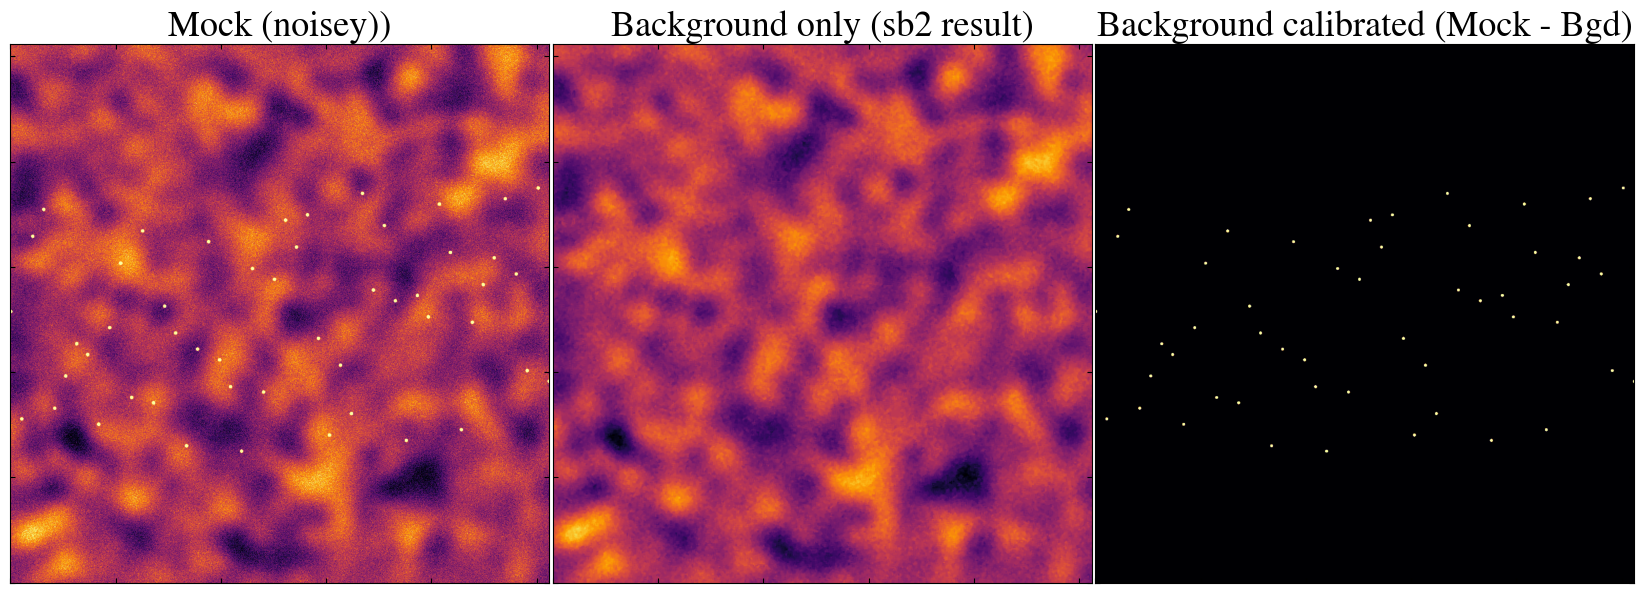

In [6]:
sim.plot_cal_steps(
    noisy_fits      = noisy_fits,
    ap_table        = clean_table,
    bgd_fits        = outdir / "gauss_noisy-bgd.fits",
    apphot_r        = arg_apphot_r,
    sky_rin         = arg_sky_rin,
    sky_rout        = arg_sky_rout,
    save            = False,
)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from photutils.datasets import make_100gaussians_image
from photutils.aperture import CircularAperture, aperture_photometry

# 1. Load or generate a simple test image with sources
data = make_100gaussians_image()

# 2. Define the pixel positions (x, y) of the source(s)
positions = [(150.0, 25.0), (90.0, 60.0)]  # Example coordinates

# 3. Create a circular aperture at those positions with radius r = 4.0 pixels
apertures = CircularAperture(positions, r=4.0)

# 4. Perform aperture photometry
phot_table = aperture_photometry(data, apertures)

# 5. Print the resulting table with measured fluxes
print(phot_table)

 id x_center y_center    aperture_sum  
--- -------- -------- -----------------
  1    150.0     25.0  241.999310632018
  2     90.0     60.0 736.3180102136439


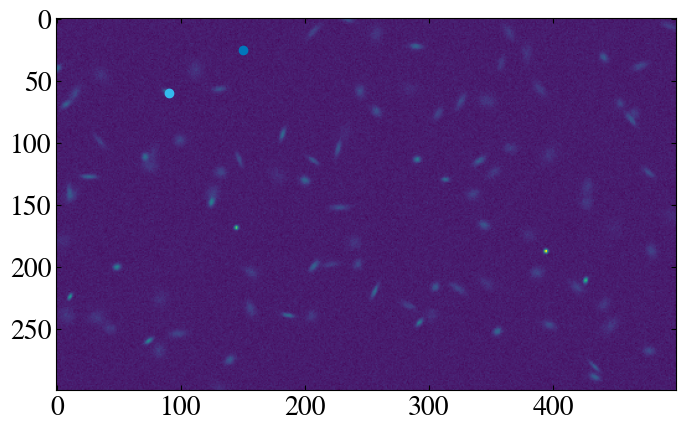

In [11]:
plt.imshow(data)
plt.scatter(*positions[0])
plt.scatter(*positions[1])

In [12]:
def smooth(sigma, R1=2, R2=3):
    return (R1/R2)**2 * (1-np.exp(-R2**2/(2*sigma)))/ (1-np.exp(-R1**2/(2*sigma)))


print(smooth(sigma=0.5))
print(smooth(sigma=50))


0.4526807324704445
0.9755740728811134
